In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def forest_plot_helper(axs, data_df, model_df, metric):

    # extract data
    data_point = data_df[f"{metric}_point"].values
    model_lbs = model_df[f"{metric}_lb"].values
    model_ubs = model_df[f"{metric}_ub"].values
    model_point = model_df[f"{metric}_point"].values

    # compute fit relative to data
    relative_lbs = model_lbs - data_point
    relative_ubs = model_ubs - data_point
    relative_point = model_point - data_point

    # forest plot
    for r, (lb, pt, ub) in enumerate(zip(relative_lbs, relative_point, relative_ubs)):
        if lb < 0 and ub > 0:
            color = "green"
        else:
            color = "red"
        axs.plot([lb, ub], [r, r], color=color)
        axs.scatter([pt], [r], color=color, s=5)
        axs.axvline(0, color="black", alpha=0.25)

In [3]:
def forest_plot(data_name, model_name, figsize=(24, 4)):

    # load data
    data_df = pd.read_csv(f"./data/{data_name}.csv")
    model_df = pd.read_csv(f"./data/{data_name}-{model_name}.csv", index_col=0)

    # select metrics
    metrics = [
        "mean_1",
        "mean_2",
        "vars_1",
        "vars_2",
        "prsn",
        "sprm"
    ]
    names = [
        "Mean 1",
        "Mean 2",
        "Variance 1",
        "Variance 2",
        "Pearson Correlation",
        "Spearman Correlation"
    ]

    # plot
    fig, axs = plt.subplots(1, 6, figsize=(24, 4))

    for i, metric in enumerate(metrics):
        forest_plot_helper(axs[i], data_df, model_df, metric)
        axs[i].set_title(names[i])

    fig.supxlabel("Statistic relative to observed data")
    fig.suptitle(f"Posterior Predictive Intervals: (data) {data_name}, (model) {model_name}")
    axs[0].set_ylabel("Repeats")
    
    plt.show()

In [4]:
def coverage(data_name, model_name):

    # load data
    data_df = pd.read_csv(f"./data/{data_name}.csv")
    model_df = pd.read_csv(f"./data/{data_name}-{model_name}.csv", index_col=0)

    # select metrics
    metrics = [
        "mean_1",
        "mean_2",
        "vars_1",
        "vars_2",
        "prsn",
        #"sprm"
    ]

    # compute coverage
    coverage_dict = {}
    for metric in metrics:
        coverage_dict[metric] = np.mean(
            (model_df[f"{metric}_lb"] <= data_df[f"{metric}_point"]) &
            (model_df[f"{metric}_ub"] >= data_df[f"{metric}_point"])
        )
    coverage_dict['total'] = np.mean(list(coverage_dict.values()))
    coverage_df = pd.DataFrame(coverage_dict, index=[0])
    return coverage_df

In [5]:
def summary_table(data_names, model_names):

    table = pd.DataFrame(columns=["data", "model", "mean_1", "mean_2", "vars_1", "vars_2", "prsn", "total"])
    for model_name in model_names:
        for data_name in data_names:
            try:
                coverage_df = coverage(data_name, model_name)
            except:
                continue
            coverage_df["data"] = data_name
            coverage_df["model"] = model_name
            table = pd.concat([table, coverage_df], ignore_index=True)

    return table.style.background_gradient(axis=0, subset=["mean_1", "mean_2", "vars_1", "vars_2", "prsn", "total"])

In [46]:
def single_metric_summary_table(data_names, model_names, metric):

    matrix = np.zeros((len(data_names), len(model_names)))
    for i, data_name in enumerate(data_names):
        for j, model_name in enumerate(model_names):
            coverage_df = coverage(data_name, model_name)
            matrix[i, j] = coverage_df[metric].item()
    
    table = pd.DataFrame(
        matrix,
        columns=model_names,
        index=data_names
    )

    return table.style.background_gradient(axis=1)

## Coverage table

In [31]:
summary_table(
    ["real-data", "lognormal-nb", "copula-nb", "indep-nb", "indep-poi"],
    ["NB-128-2-1-400", "NB-16-2-1-400"]
)

,data,model,mean_1,mean_2,vars_1,vars_2,prsn,total
0,real-data,NB-128-2-1-400,0.600000,0.666667,0.666667,0.500000,0.766667,0.640000
1,lognormal-nb,NB-128-2-1-400,0.766667,0.766667,0.866667,1.000000,0.466667,0.773333
2,copula-nb,NB-128-2-1-400,0.400000,0.400000,0.000000,0.000000,0.000000,0.160000
3,indep-nb,NB-128-2-1-400,0.433333,0.400000,0.033333,0.100000,0.133333,0.220000
4,indep-poi,NB-128-2-1-400,0.366667,0.400000,0.000000,0.000000,0.000000,0.153333
5,real-data,NB-16-2-1-400,0.766667,0.800000,0.666667,0.766667,0.766667,0.753333
6,lognormal-nb,NB-16-2-1-400,0.966667,0.933333,0.900000,0.933333,0.300000,0.806667
7,copula-nb,NB-16-2-1-400,0.666667,0.700000,0.000000,0.000000,0.000000,0.273333
8,indep-nb,NB-16-2-1-400,0.600000,0.600000,0.000000,0.033333,0.000000,0.246667
9,indep-poi,NB-16-2-1-400,0.700000,0.733333,0.000000,0.000000,0.000000,0.286667


Summary
- smaller model performs better overall: should be enough training time, maybe not
- good performance on real data
- best performance on lognormal data: EM-VAE-scVI comparison work supports this
- except for correlation: fit much better on real data
- poor performance on other simulated data: smaller model fits means better but still fails badly on all else

Note
- not included is spearman correlation, which has ~0% coverage being almost always overestimated

### Example plots

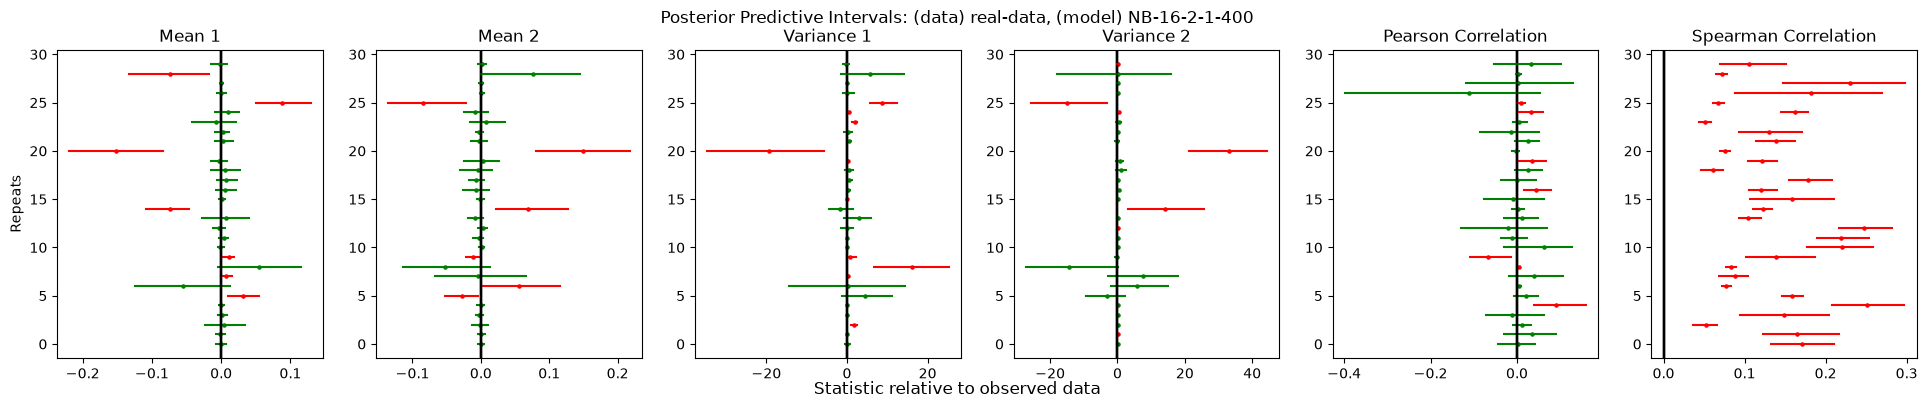

In [32]:
forest_plot("real-data", "NB-16-2-1-400")

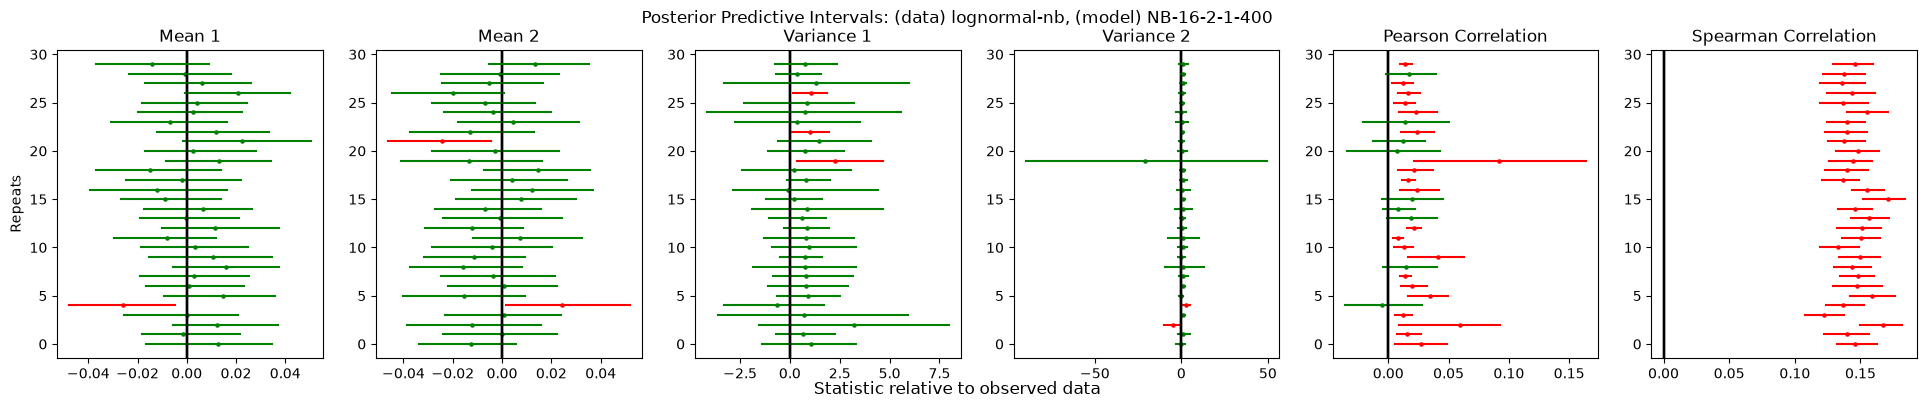

In [33]:
forest_plot("lognormal-nb", "NB-16-2-1-400")

# Updates

- larger models fit correlation better
- smaller models fit better overall

In [7]:
summary_table(
    ["real-data", "lognormal-nb", "lognormal-poi", "copula-nb", "copula-poi", "indep-nb", "indep-poi"],
    ["NB-128-2-1-400", "NB-16-2-1-400", "NB-4-2-1-400"]
)

,data,model,mean_1,mean_2,vars_1,vars_2,prsn,total
0,real-data,NB-128-2-1-400,0.600000,0.666667,0.666667,0.500000,0.766667,0.640000
1,lognormal-nb,NB-128-2-1-400,0.766667,0.766667,0.866667,1.000000,0.466667,0.773333
2,lognormal-poi,NB-128-2-1-400,0.633333,0.633333,0.666667,0.800000,0.366667,0.620000
3,copula-nb,NB-128-2-1-400,0.400000,0.400000,0.000000,0.000000,0.000000,0.160000
4,copula-poi,NB-128-2-1-400,0.366667,0.333333,0.000000,0.000000,0.033333,0.146667
5,indep-nb,NB-128-2-1-400,0.433333,0.400000,0.033333,0.100000,0.133333,0.220000
6,indep-poi,NB-128-2-1-400,0.366667,0.400000,0.000000,0.000000,0.000000,0.153333
7,real-data,NB-16-2-1-400,0.766667,0.800000,0.666667,0.766667,0.766667,0.753333
8,lognormal-nb,NB-16-2-1-400,0.966667,0.933333,0.900000,0.933333,0.300000,0.806667
9,lognormal-poi,NB-16-2-1-400,0.966667,0.966667,0.700000,0.766667,0.233333,0.726667


In [47]:
single_metric_summary_table(
    ["real-data", "lognormal-nb", "lognormal-poi", "copula-nb", "copula-poi", "indep-nb", "indep-poi"],
    ["NB-128-2-1-400", "NB-16-2-1-400", "NB-4-2-1-400"],
    "total"
)

,NB-128-2-1-400,NB-16-2-1-400,NB-4-2-1-400
real-data,0.640000,0.753333,0.740000
lognormal-nb,0.773333,0.806667,0.766667
lognormal-poi,0.620000,0.726667,0.753333
copula-nb,0.160000,0.273333,0.366667
copula-poi,0.146667,0.333333,0.360000
indep-nb,0.220000,0.246667,0.446667
indep-poi,0.153333,0.286667,0.386667


In [48]:
single_metric_summary_table(
    ["real-data", "lognormal-nb", "lognormal-poi", "copula-nb", "copula-poi", "indep-nb", "indep-poi"],
    ["NB-128-2-1-400", "NB-16-2-1-400", "NB-4-2-1-400"],
    "prsn"
)

,NB-128-2-1-400,NB-16-2-1-400,NB-4-2-1-400
real-data,0.766667,0.766667,0.333333
lognormal-nb,0.466667,0.300000,0.066667
lognormal-poi,0.366667,0.233333,0.000000
copula-nb,0.000000,0.000000,0.000000
copula-poi,0.033333,0.033333,0.033333
indep-nb,0.133333,0.000000,0.000000
indep-poi,0.000000,0.000000,0.000000


## Library size choices

- padding with constant gene much better than fixed library sizes
- fixed values: rescaled real total counts much better than constant

In [49]:
summary_table(
    ["real-data"],
    ["NB-16-2-1-400", "NB-16-2-1-400-pad", "NB-16-2-1-400-const", "NB-16-2-1-400-real"]
)

,data,model,mean_1,mean_2,vars_1,vars_2,prsn,total
0,real-data,NB-16-2-1-400,0.766667,0.800000,0.666667,0.766667,0.766667,0.753333
1,real-data,NB-16-2-1-400-pad,0.666667,0.633333,0.600000,0.633333,0.600000,0.626667
2,real-data,NB-16-2-1-400-const,0.366667,0.500000,0.333333,0.333333,0.266667,0.360000
3,real-data,NB-16-2-1-400-real,0.566667,0.600000,0.500000,0.500000,0.200000,0.473333
